In [ ]:
import pandas as pd
import numpy as np

# keep this cell for imports

In [2]:
# Data load & basic cleaning: read both CSVs and concatenate
mat = pd.read_csv('dataset/student-mat.csv', sep=';', quotechar='"')
por = pd.read_csv('dataset/student-por.csv', sep=';', quotechar='"')
mat['subject'] = 'math'
por['subject'] = 'por'
df = pd.concat([mat, por], ignore_index=True)

# Convert some binary yes/no columns to 0/1 (if present)
bin_cols = ['schoolsup','famsup','paid','activities','nursery','higher','internet','romantic']
for c in bin_cols:
    if c in df.columns:
        df[c] = df[c].map({'yes':1, 'no':0, 'Yes':1, 'No':0}).fillna(df[c])

# Ensure numeric columns are numeric
num_cols = ['G1','G2','G3','age','absences','Medu','Fedu','traveltime','studytime','failures','famrel','freetime','goout','Dalc','Walc','health']
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Quick shape and dtypes check
print('combined shape:', df.shape)
print(df.dtypes[['G1','G2','G3']])
df.head()

combined shape: (1044, 34)
G1    int64
G2    int64
G3    int64
dtype: object


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,math
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,math
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,math
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,math
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,math


Top correlations with G3:
G3           1.000000
G2           0.910743
G1           0.809142
failures     0.383145
higher       0.236578
Medu         0.201472
studytime    0.161629
Fedu         0.159796
Dalc         0.129642
age          0.125282
Walc         0.115740
internet     0.107064
dtype: float64


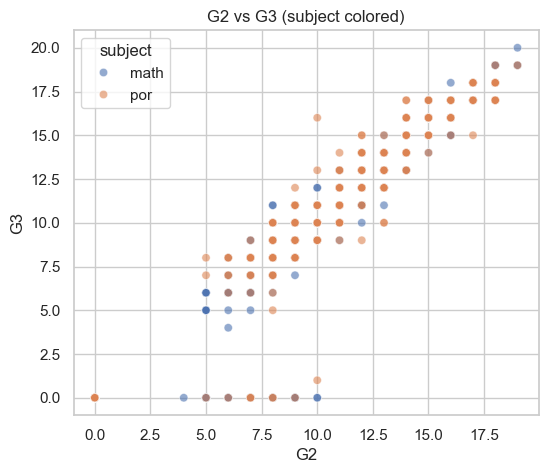

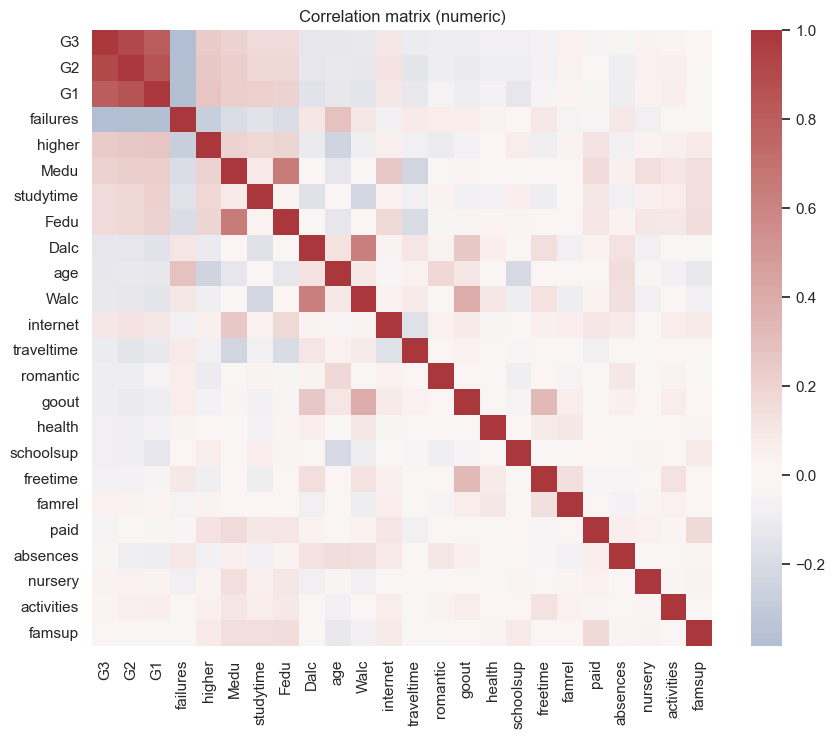

In [3]:
# Correlation analysis: numeric cols vs G3
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style='whitegrid')

num_df = df.select_dtypes(include=[np.number])
if 'G3' in num_df.columns:
    corr_with_G3 = num_df.corrwith(num_df['G3']).abs().sort_values(ascending=False)
    print('Top correlations with G3:')
    print(corr_with_G3.head(12))
else:
    print('G3 not found in numeric columns')

# Scatter G2 vs G3
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x='G2', y='G3', hue='subject', alpha=0.6)
plt.title('G2 vs G3 (subject colored)')
plt.show()

# Correlation heatmap (numeric) ordered by |corr(G3, x)|
corr = num_df.corr()
if 'G3' in corr.columns:
    order = corr['G3'].abs().sort_values(ascending=False).index
else:
    order = corr.columns
plt.figure(figsize=(10,8))
sns.heatmap(corr.loc[order, order], annot=False, cmap='vlag', center=0)
plt.title('Correlation matrix (numeric)')
plt.show()

## Visualizaciones recomendadas
A continuación se añaden varias visualizaciones prioritarias para explorar `G3` (nota final):

1. Distribución de `G3` por materia (histograma + KDE)
2. Boxplots de `G3` por `sex` y por niveles de `Medu`/`Fedu`
3. Scatter `G3` vs `absences` con una curva LOESS (lowess)
4. Pairplot reducido para `G1`, `G2`, `G3`, `absences`, `studytime` y `failures`

Las celdas siguientes generan estas gráficas usando seaborn/matplotlib.

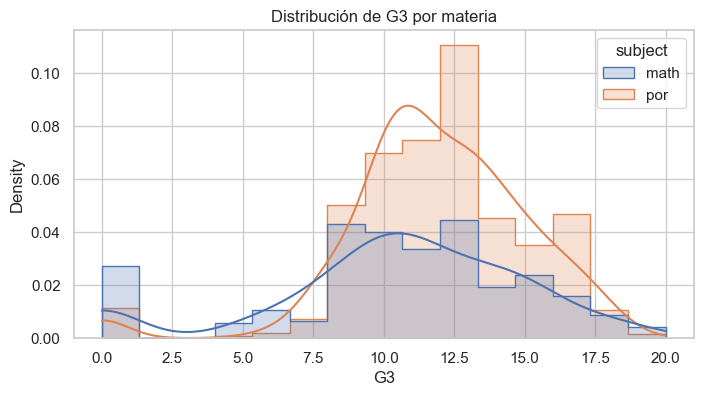

In [4]:
# 1) Histograma + KDE de G3 por subject
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='G3', hue='subject', kde=True, bins=15, element='step', stat='density')
plt.title('Distribución de G3 por materia')
plt.show()

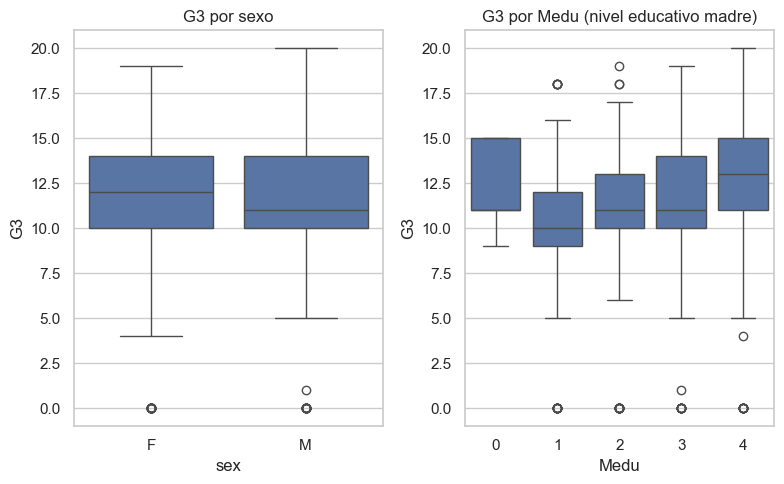

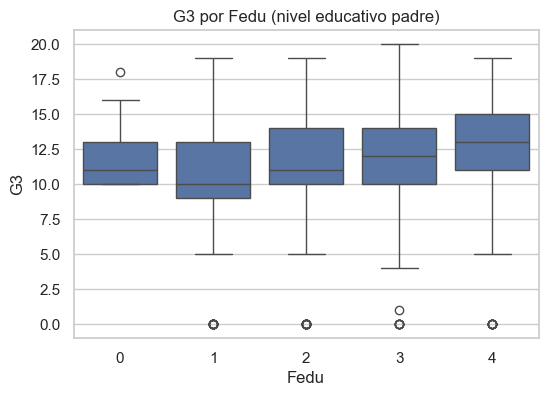

In [5]:
# 2) Boxplots: G3 por sex y por niveles de Medu / Fedu
plt.figure(figsize=(8,5))
plt.subplot(1,2,1)
sns.boxplot(data=df, x='sex', y='G3')
plt.title('G3 por sexo')
plt.subplot(1,2,2)
sns.boxplot(data=df, x='Medu', y='G3')
plt.title('G3 por Medu (nivel educativo madre)')
plt.tight_layout()
plt.show()

# Fedu
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Fedu', y='G3')
plt.title('G3 por Fedu (nivel educativo padre)')
plt.show()

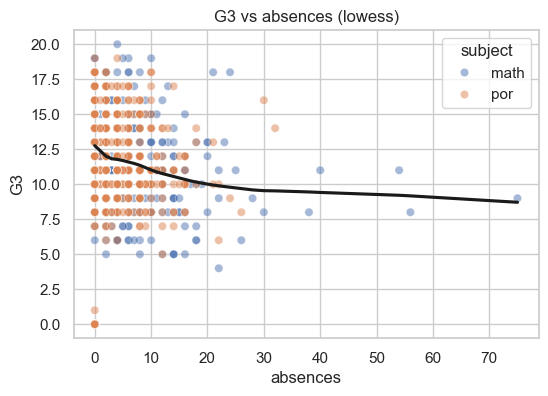

In [6]:
# 3) G3 vs absences con lowess (LOESS-like) usando seaborn.regplot (lowess=True)
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='absences', y='G3', hue='subject', alpha=0.5)
sns.regplot(data=df, x='absences', y='G3', scatter=False, lowess=True, color='k')
plt.title('G3 vs absences (lowess)')
plt.show()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


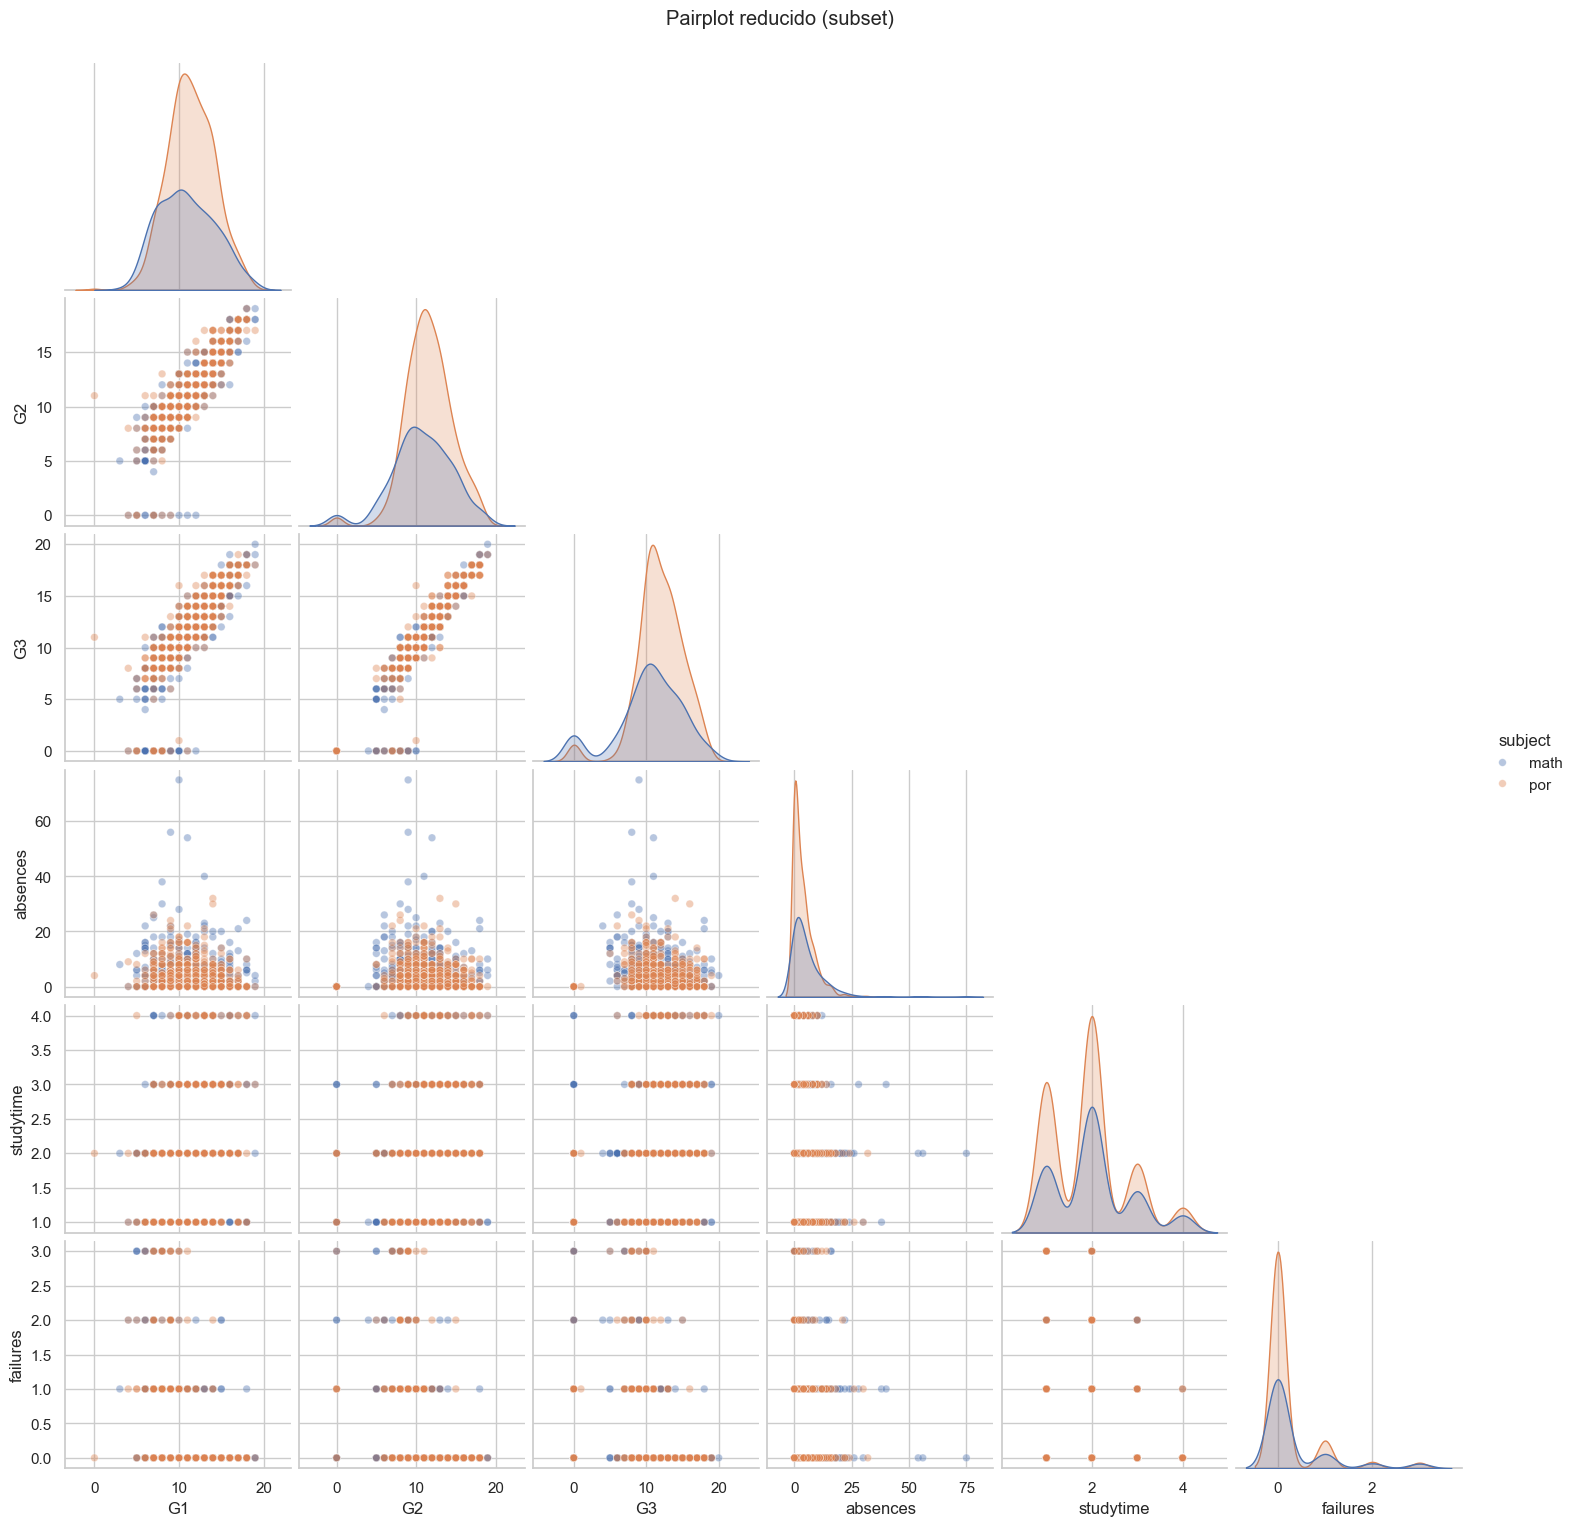

In [7]:
# 4) Pairplot reducido para ver relaciones entre G1,G2,G3,absences,studytime,failures
vars_subset = ['G1','G2','G3','absences','studytime','failures']
# drop rows with NA in the subset to avoid errors
subset_df = df.dropna(subset=vars_subset)
# pairplot
sns.pairplot(subset_df[vars_subset + ['subject']], vars=vars_subset, hue='subject', corner=True, plot_kws={'alpha':0.4, 's':30})
plt.suptitle('Pairplot reducido (subset)', y=1.02)
plt.show()

### Gráficas entre variables continuas
A continuación generamos gráficos especialmente pensados para explorar relaciones entre variables continuas (o contínuo-like). Veremos: conteos de valores únicos, pares más correlacionados, scatter+línea de regresión para los pares principales, jointplots con densidad/regresión, y mapas hexbin/2D KDE para parejas claves.

In [8]:
# 1) Identificar variables continuas (numéricas con suficientes valores únicos)
num_df = df.select_dtypes(include=[np.number]).copy()
unique_counts = num_df.nunique().sort_values(ascending=False)
print('Unique counts (numeric cols):')
print(unique_counts.head(20))

# Seleccionar continuas: más de 6 valores únicos (heurística)
cont_vars = unique_counts[unique_counts > 6].index.tolist()
print('\nContinuous-like variables:', cont_vars)

# Calcular correlaciones y top pares absolutos (excluyendo auto-corr)
corr = num_df.corr().abs()
# get top pairs
pairs = []
for i, c1 in enumerate(corr.columns):
    for j, c2 in enumerate(corr.columns):
        if j > i:
            pairs.append((c1, c2, corr.loc[c1, c2]))
pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)
print('\nTop 10 correlated numeric pairs:')
for a,b,v in pairs_sorted[:10]:
    print(f"{a} - {b}: {v:.3f}")

# Guardar top pares para graficar
top_pairs = pairs_sorted[:6]

Unique counts (numeric cols):
absences      35
G3            19
G1            18
G2            17
age            8
famrel         5
freetime       5
Fedu           5
health         5
Walc           5
Medu           5
Dalc           5
goout          5
traveltime     4
studytime      4
failures       4
schoolsup      2
romantic       2
higher         2
nursery        2
dtype: int64

Continuous-like variables: ['absences', 'G3', 'G1', 'G2', 'age']

Top 10 correlated numeric pairs:
G2 - G3: 0.911
G1 - G2: 0.859
G1 - G3: 0.809
Medu - Fedu: 0.642
Dalc - Walc: 0.628
goout - Walc: 0.400
failures - G3: 0.383
failures - G2: 0.377
failures - G1: 0.374
freetime - goout: 0.324


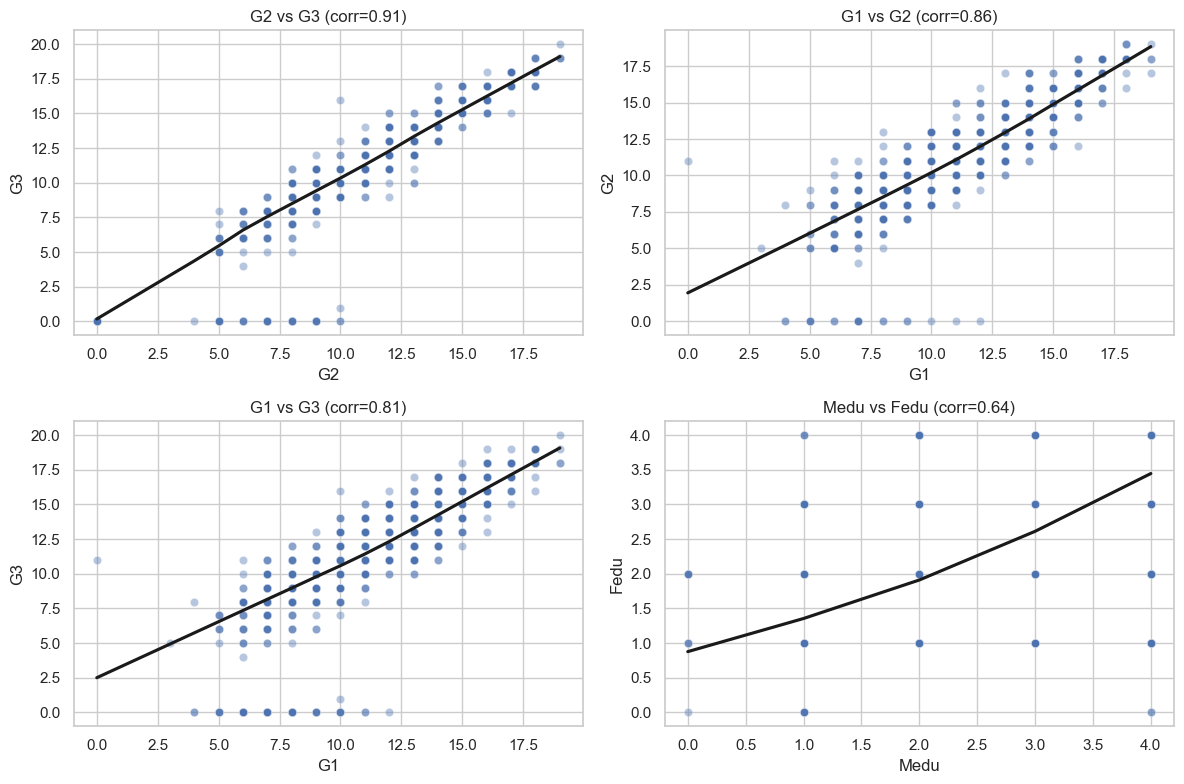

In [9]:
# 2) Scatter + reg para top correlated pairs
plt.figure(figsize=(12,8))
for idx, (a,b,v) in enumerate(top_pairs[:4], start=1):
    plt.subplot(2,2,idx)
    sns.scatterplot(data=num_df, x=a, y=b, alpha=0.4)
    sns.regplot(data=num_df, x=a, y=b, scatter=False, lowess=True, color='k')
    plt.title(f'{a} vs {b} (corr={v:.2f})')
plt.tight_layout()
plt.show()

Jointplot variables vs G3: ['G2', 'G1', 'age', 'absences']


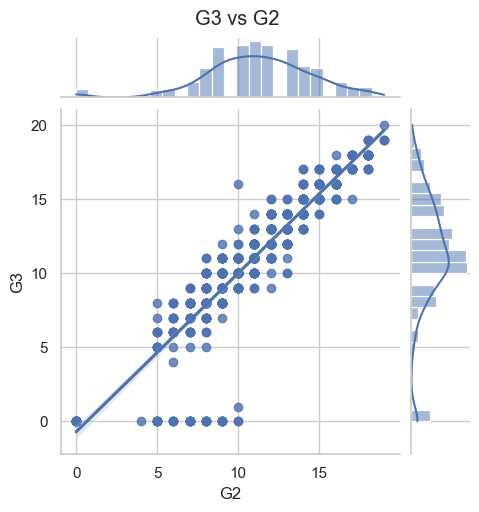

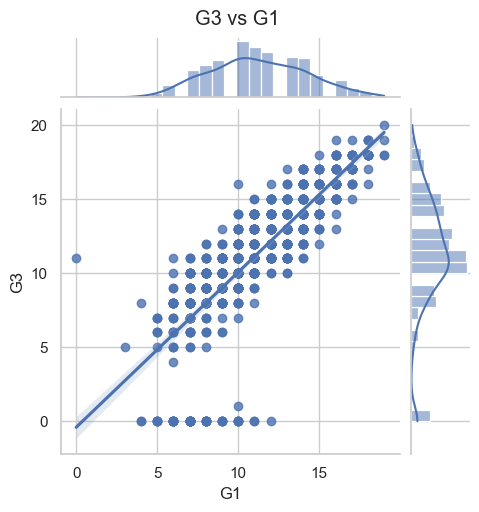

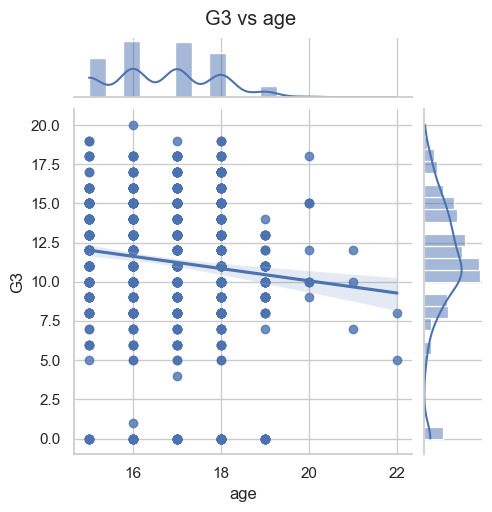

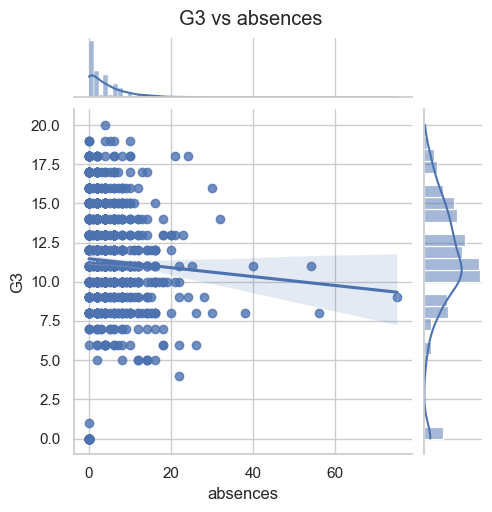

In [10]:
# 3) Jointplots (G3 vs top continuous variables) - show density and regression
# Elegir las top 4 variables continuas más correlacionadas con G3 (excluyendo G1/G2 si quieres enfocarte)
candidates = corr['G3'].abs().sort_values(ascending=False).index.tolist()
# quitar G3
candidates = [c for c in candidates if c != 'G3']
joint_vars = [c for c in candidates if c in cont_vars][:4]
print('Jointplot variables vs G3:', joint_vars)

for v in joint_vars:
    sns.jointplot(data=num_df, x=v, y='G3', kind='reg', height=5)
    plt.suptitle(f'G3 vs {v}', y=1.02)
plt.show()

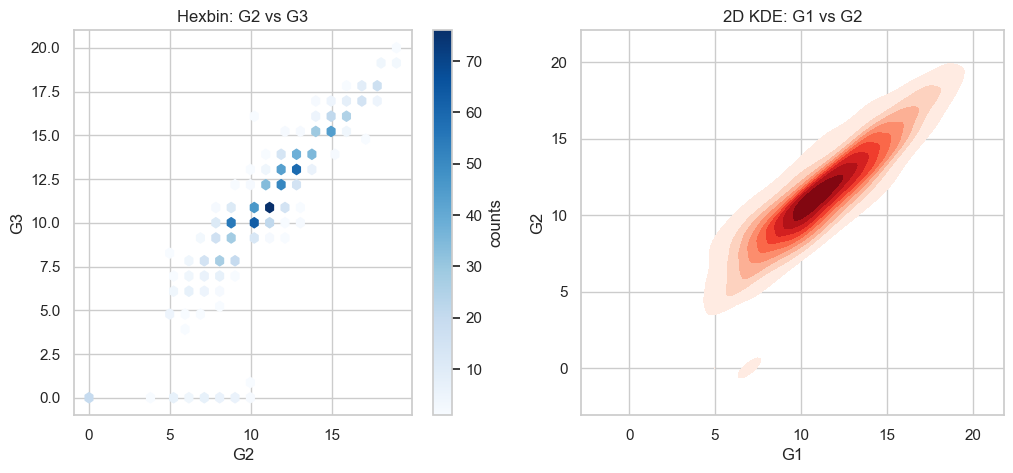

In [11]:
# 4) Hexbin / 2D KDE for pairs where many points overlap (choose two examples)
if len(top_pairs) >= 2:
    a,b,_ = top_pairs[0]
    c,d,_ = top_pairs[1]
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.hexbin(num_df[a].dropna(), num_df[b].dropna(), gridsize=40, cmap='Blues', mincnt=1)
    plt.xlabel(a); plt.ylabel(b); plt.title(f'Hexbin: {a} vs {b}')
    plt.colorbar(label='counts')
    plt.subplot(1,2,2)
    sns.kdeplot(x=num_df[c], y=num_df[d], fill=True, cmap='Reds', thresh=0.05)
    plt.xlabel(c); plt.ylabel(d); plt.title(f'2D KDE: {c} vs {d}')
    plt.show()
else:
    print('Not enough top pairs for hexbin/KDE')

Categorical / small-cardinality columns (heuristic):
 - subject: 2 unique
 - Dalc: 5 unique
 - Fedu: 5 unique
 - Fjob: 5 unique
 - Medu: 5 unique
 - Mjob: 5 unique
 - Pstatus: 2 unique
 - Walc: 5 unique
 - activities: 2 unique
 - address: 2 unique
 - age: 8 unique
 - failures: 4 unique
 - famrel: 5 unique
 - famsize: 2 unique
 - famsup: 2 unique
 - freetime: 5 unique
 - goout: 5 unique
 - guardian: 3 unique
 - health: 5 unique
 - higher: 2 unique
 - internet: 2 unique
 - nursery: 2 unique
 - paid: 2 unique
 - reason: 4 unique
 - romantic: 2 unique
 - school: 2 unique
 - schoolsup: 2 unique
 - sex: 2 unique
 - studytime: 4 unique
 - traveltime: 4 unique


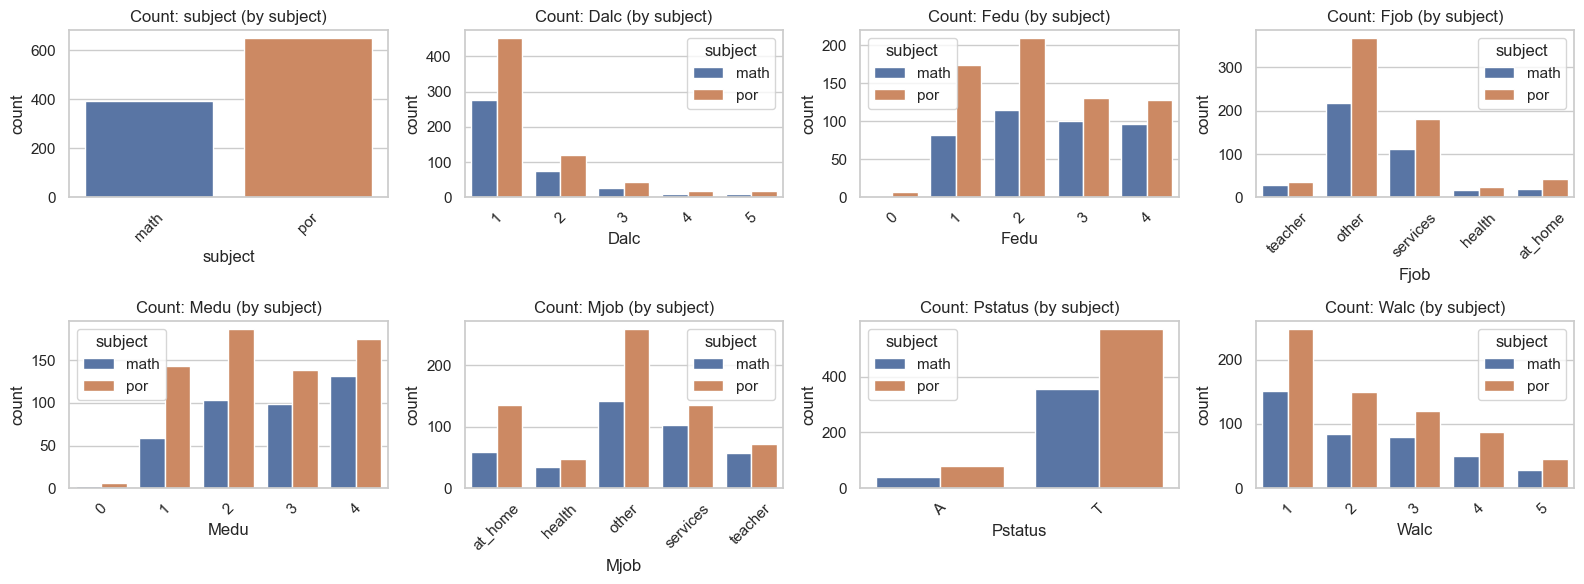

<Figure size 800x400 with 0 Axes>

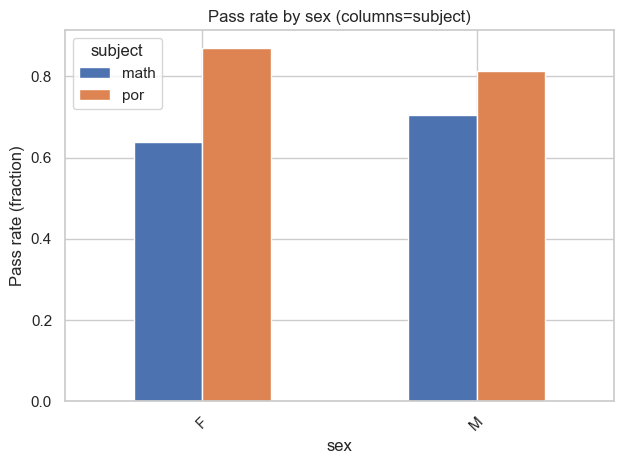

<Figure size 800x400 with 0 Axes>

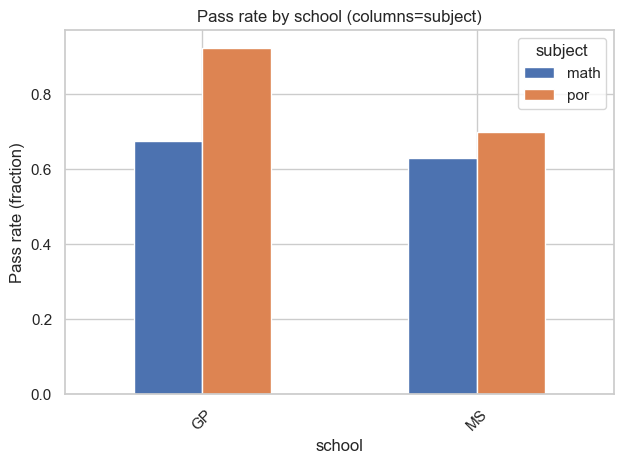

<Figure size 800x400 with 0 Axes>

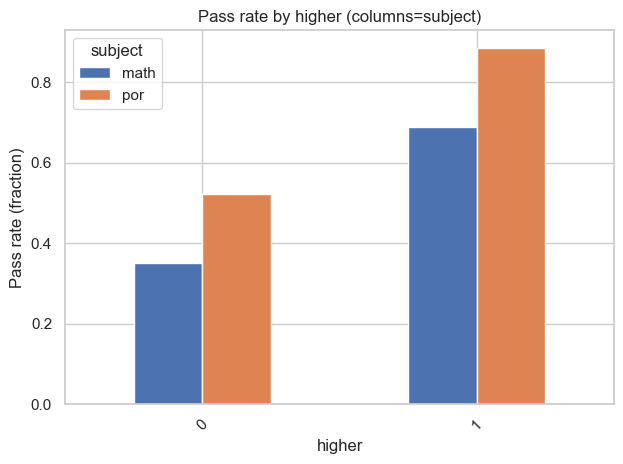

<Figure size 800x400 with 0 Axes>

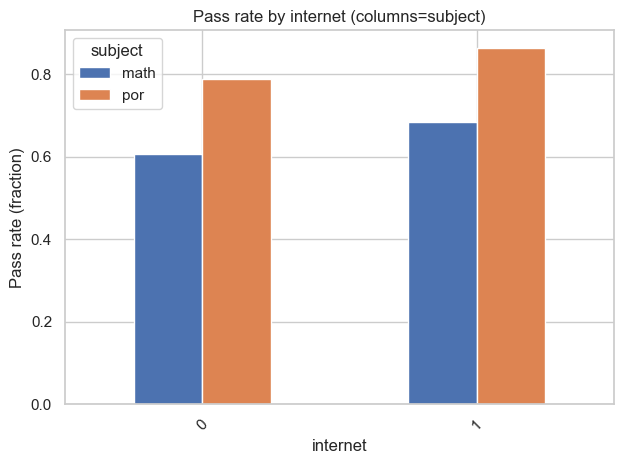

<Figure size 800x400 with 0 Axes>

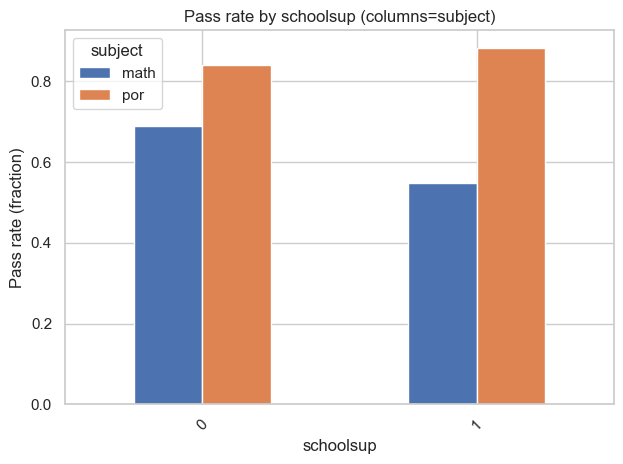

<Figure size 800x400 with 0 Axes>

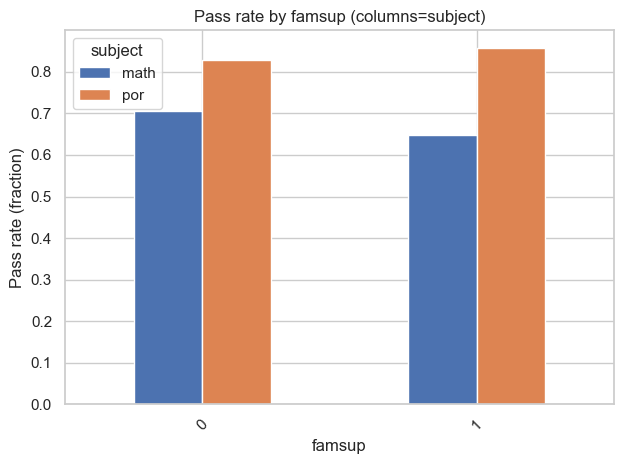

<Figure size 800x400 with 0 Axes>

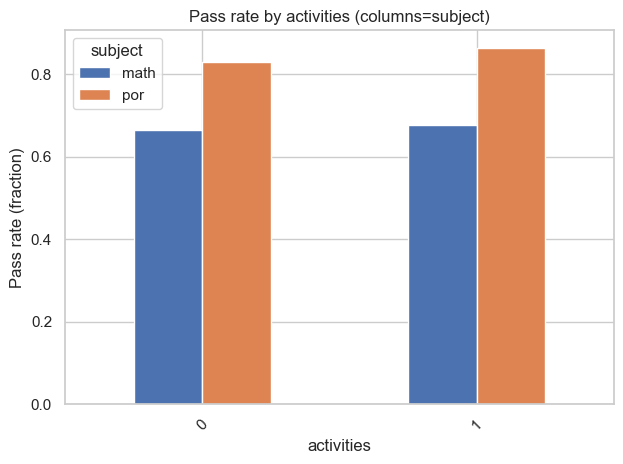

<Figure size 800x400 with 0 Axes>

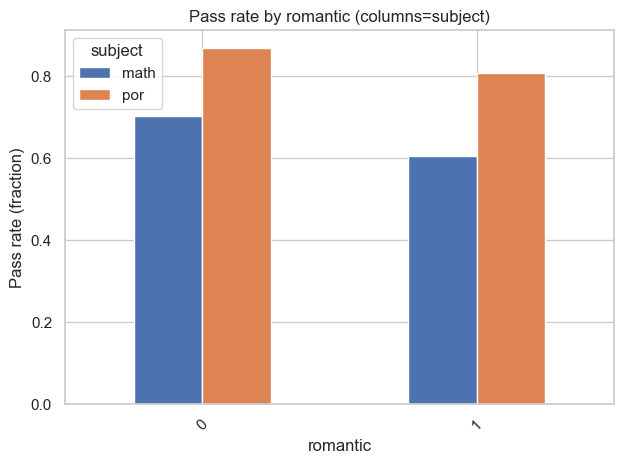

<Figure size 800x400 with 0 Axes>

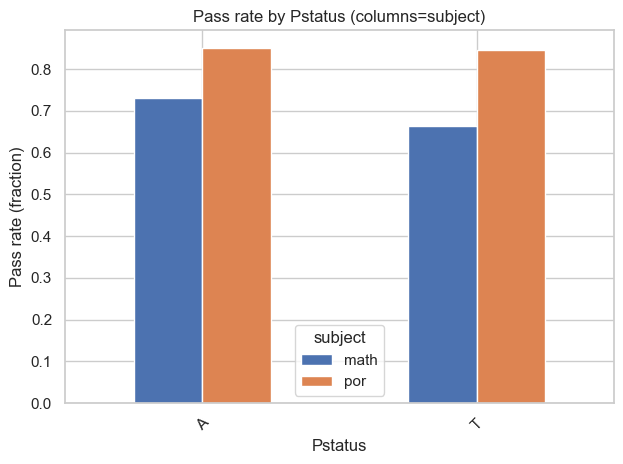

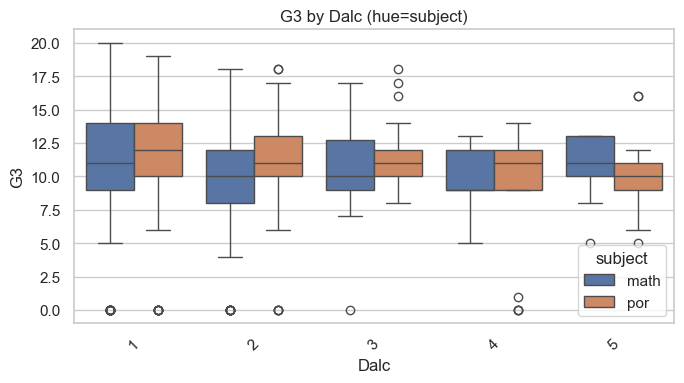

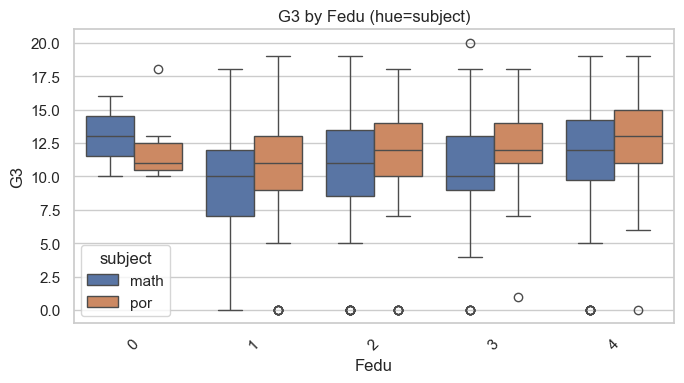

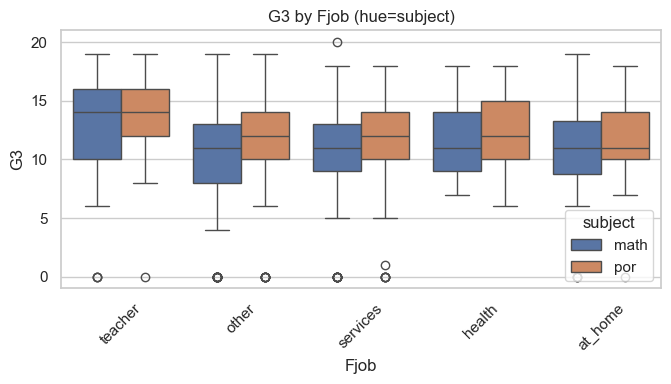

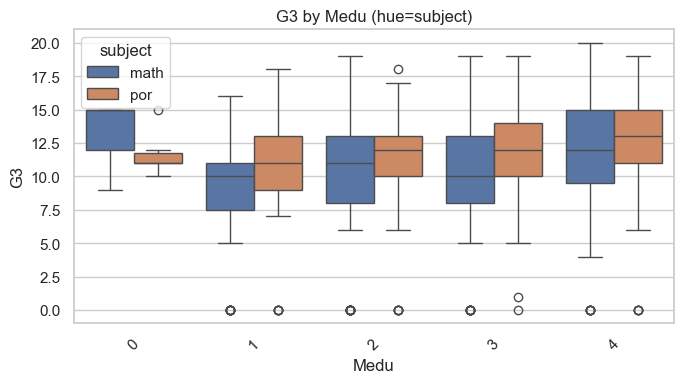

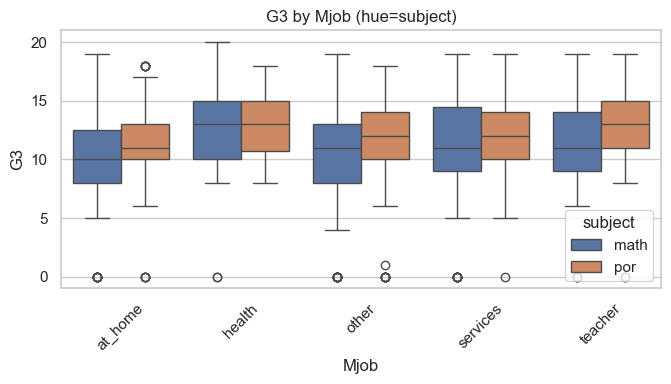

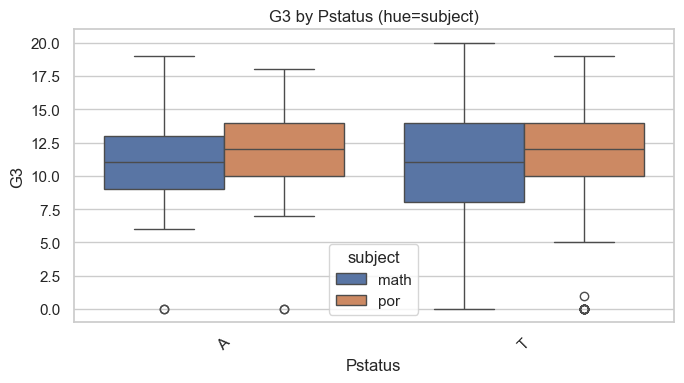

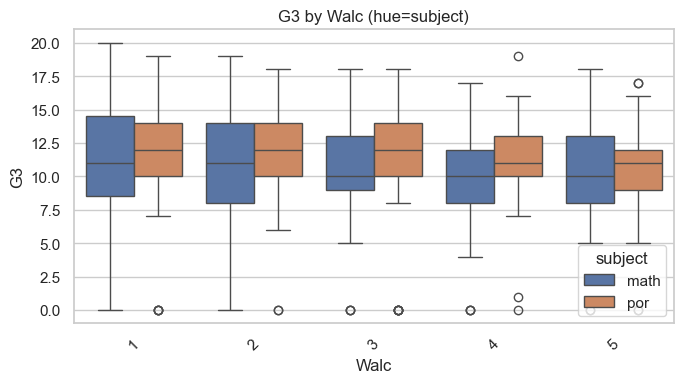

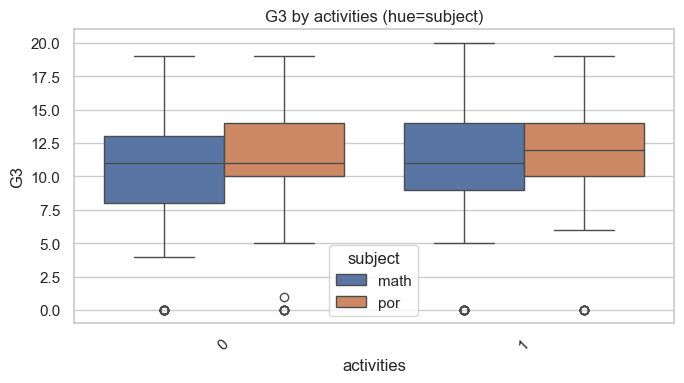

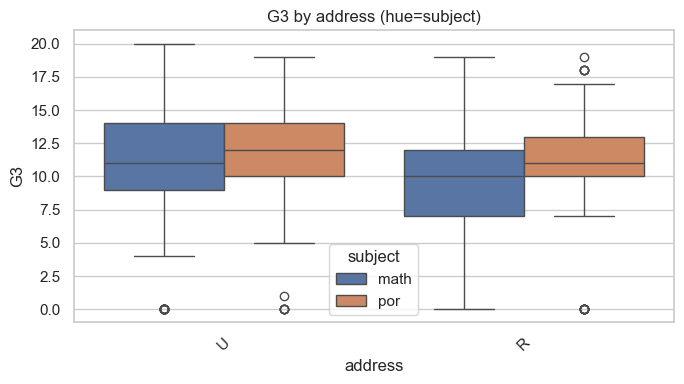

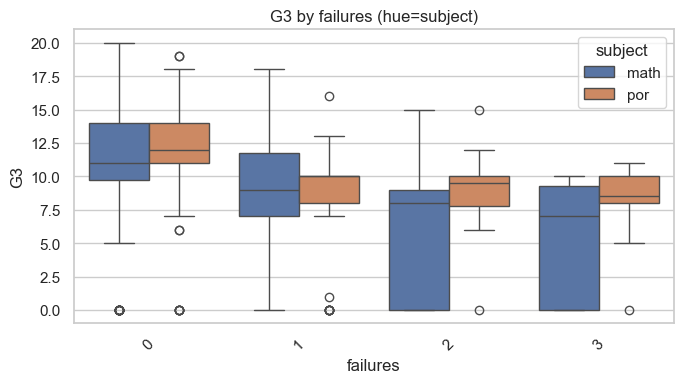

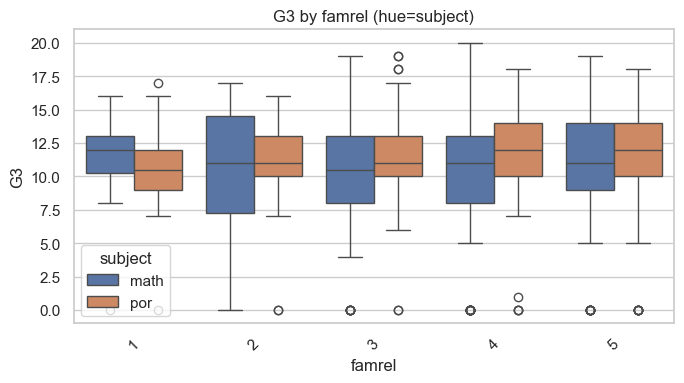

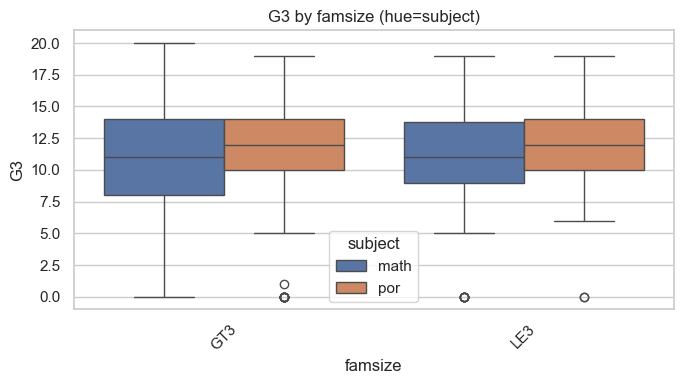

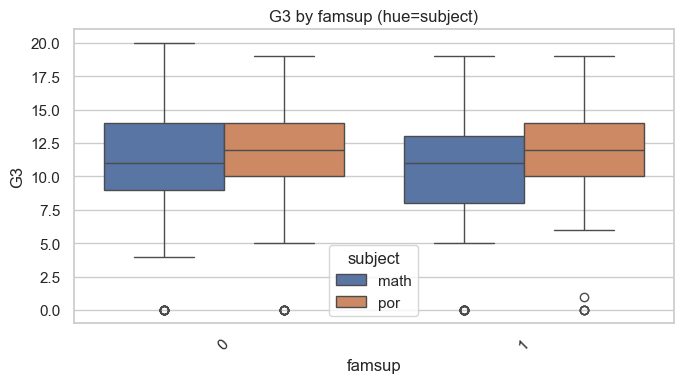

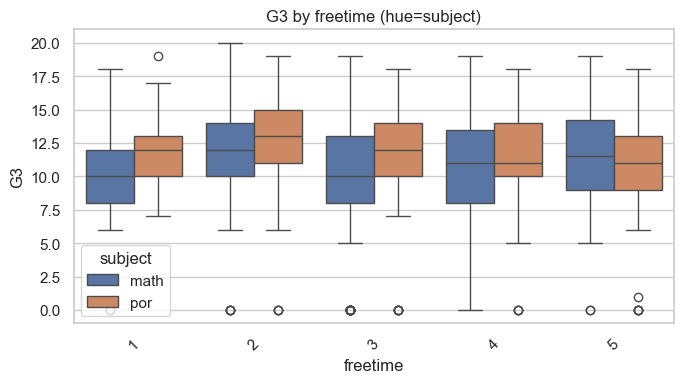

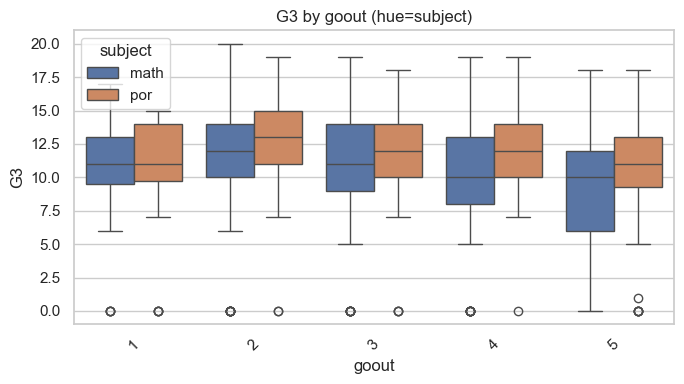

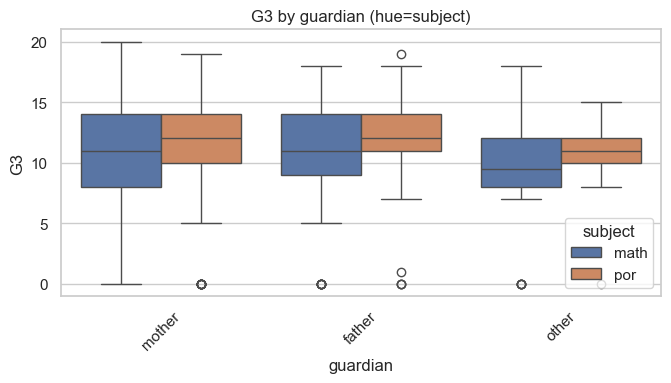

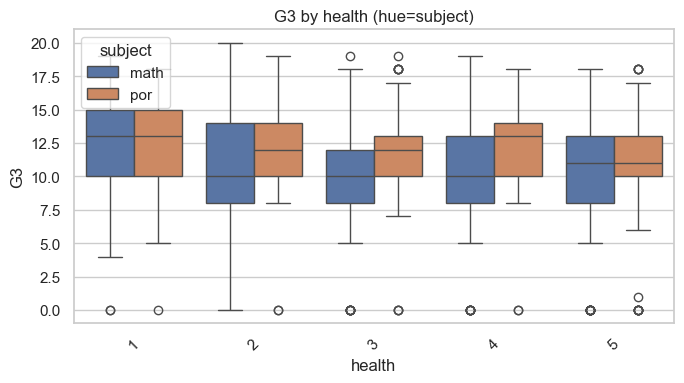

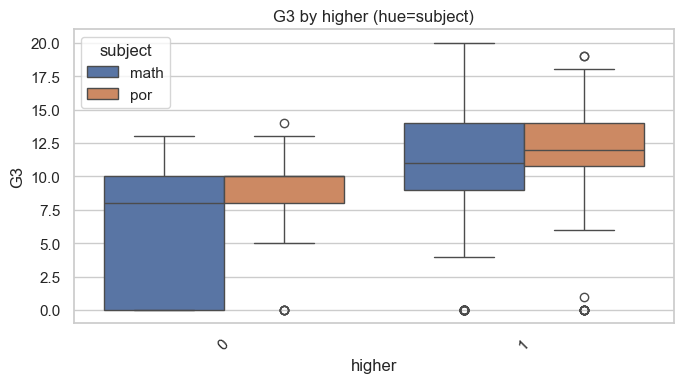

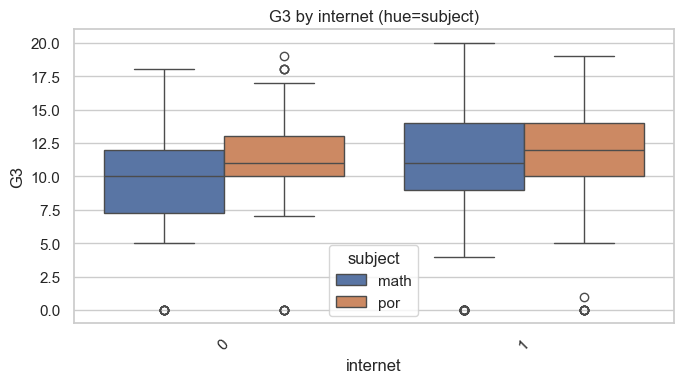

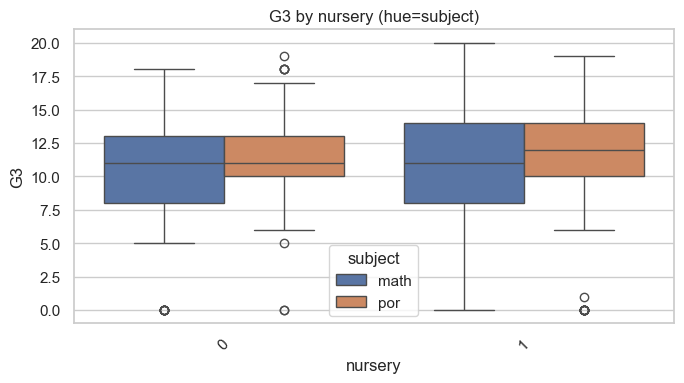

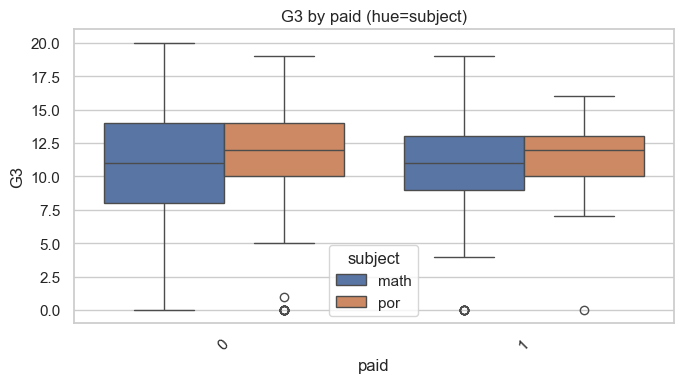

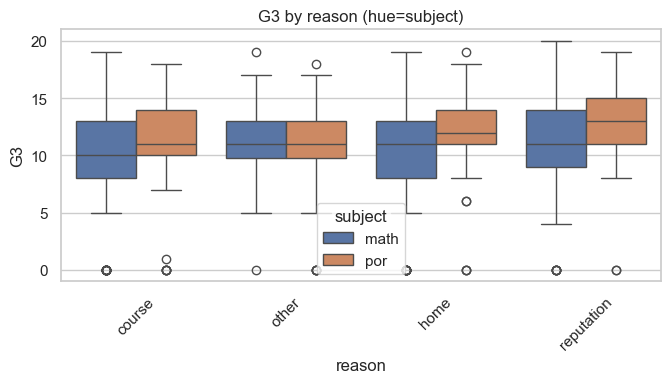

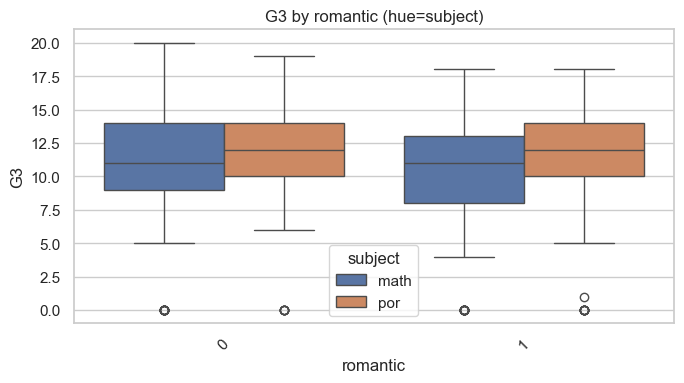

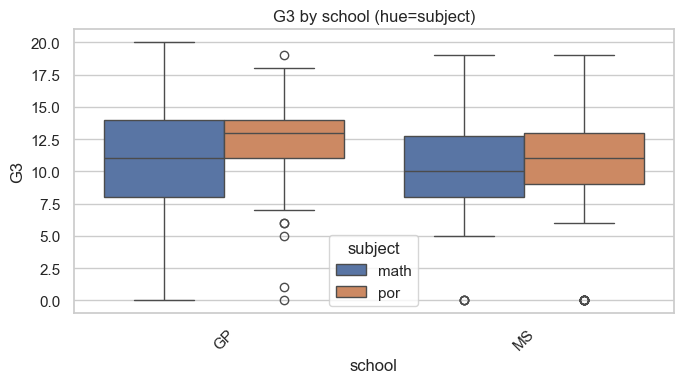

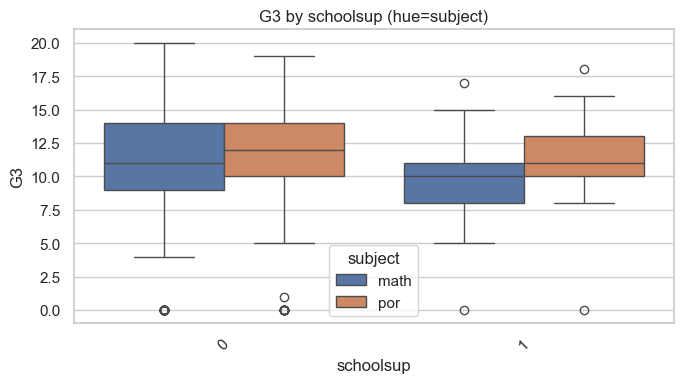

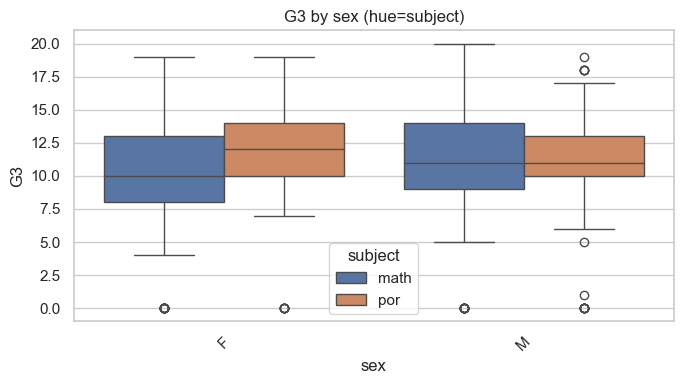

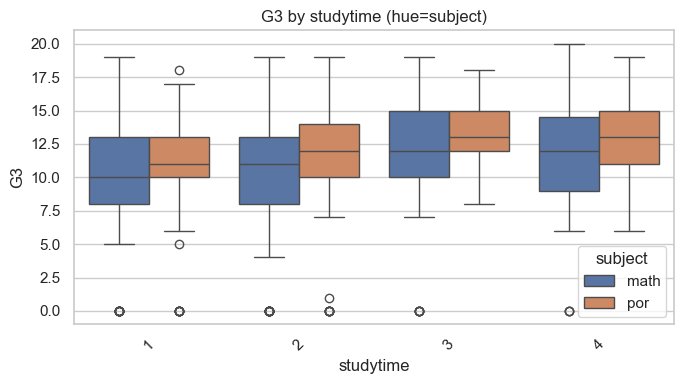

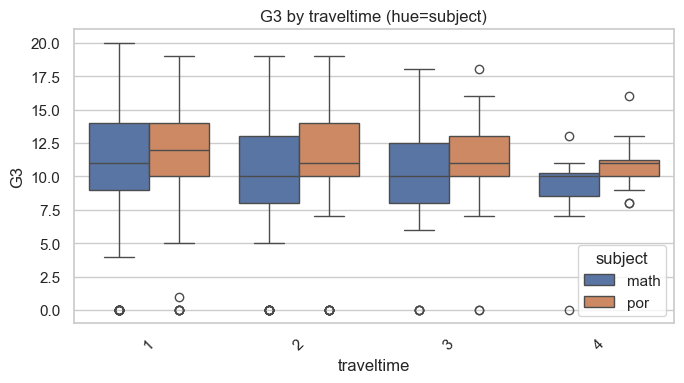

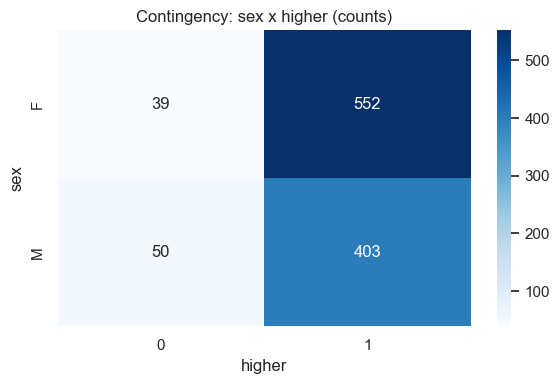

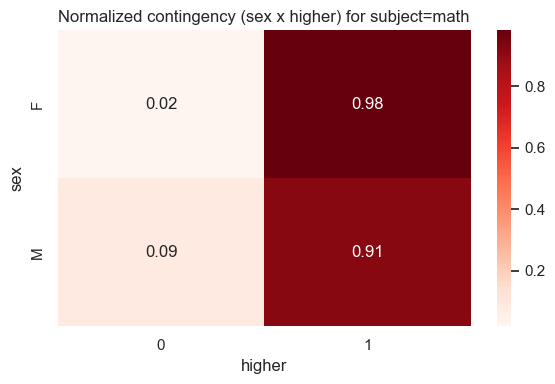

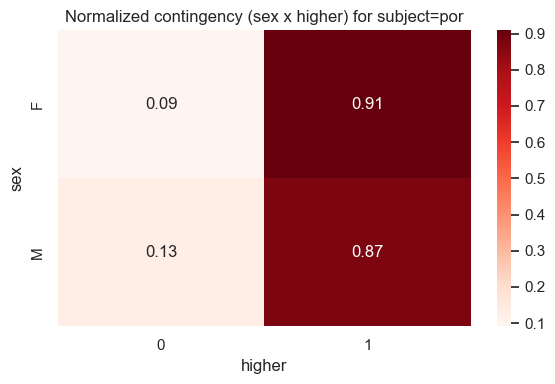


Top categorical associations by Cramer's V:
subject - paid: 0.473
age - guardian: 0.435
Dalc - Walc: 0.417
Medu - Mjob: 0.381
Fedu - Medu: 0.375
address - traveltime: 0.350
address - school: 0.342
Walc - sex: 0.326
Categorical analysis cell completed


In [12]:
# === Categorical variables analysis ===
# List candidate categorical columns and small-cardinality numeric columns
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

# Heuristic: treat object dtype and numeric cols with few unique values as categorical
obj_cols = df.select_dtypes(include=['object','category']).columns.tolist()
small_card_nums = [c for c in df.select_dtypes(include=[np.number]).columns if df[c].nunique() <= 8]
cat_candidates = sorted(list(set(obj_cols + small_card_nums)))
# Keep 'subject' early in the list if present
if 'subject' in cat_candidates:
    cat_candidates.remove('subject')
    cat_candidates.insert(0, 'subject')

print('Categorical / small-cardinality columns (heuristic):')
for c in cat_candidates:
    print(f" - {c}: {df[c].nunique()} unique")

# 1) Countplots (hue=subject) for top categorical columns (up to 8)
plot_cols = cat_candidates[:8]
n = len(plot_cols)
if n > 0:
    cols = min(4, n)
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(4*cols, 3*rows))
    for i, col in enumerate(plot_cols, 1):
        plt.subplot(rows, cols, i)
        try:
            sns.countplot(data=df, x=col, hue='subject')
            plt.xticks(rotation=45)
            plt.title(f'Count: {col} (by subject)')
        except Exception as e:
            plt.text(0.5, 0.5, f'Cannot plot {col}: {e}', ha='center')
    plt.tight_layout()
    plt.show()
else:
    print('No categorical columns found by heuristic')

# 2) Pass rate (G3 >= 10) by category and subject for selected important categorical cols
if 'G3' in df.columns:
    df['_passed'] = df['G3'] >= 10
    important_cats = [c for c in ['sex','school','higher','internet','schoolsup','famsup','activities','romantic','Pstatus'] if c in df.columns]
    for col in important_cats:
        pivot = df.groupby(['subject', col])['_passed'].mean().unstack(level=0)
        # plot normalized pass rates per category value
        plt.figure(figsize=(8,4))
        pivot.plot(kind='bar')
        plt.title(f'Pass rate by {col} (columns=subject)')
        plt.ylabel('Pass rate (fraction)')
        plt.xticks(rotation=45)
        plt.legend(title='subject')
        plt.tight_layout()
        plt.show()
else:
    print('G3 not found; cannot compute pass rates')

# 3) Boxplots of G3 by categorical variable with hue=subject (for categories with <=6 levels)
box_cols = [c for c in cat_candidates if df[c].nunique() <= 6 and c != 'subject']
for col in box_cols:
    if 'G3' in df.columns:
        plt.figure(figsize=(7,4))
        try:
            sns.boxplot(data=df, x=col, y='G3', hue='subject')
            plt.title(f'G3 by {col} (hue=subject)')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f'Could not draw boxplot for {col}: {e}')

# 4) Contingency heatmaps for pairs of categorical variables (example: sex vs higher, and subject-separated)
pairs_to_show = []
if 'sex' in df.columns and 'higher' in df.columns:
    pairs_to_show.append(('sex','higher'))
# add a fallback pair
if len(pairs_to_show) == 0 and len(cat_candidates) >= 2:
    pairs_to_show.append((cat_candidates[0], cat_candidates[1]))

for a,b in pairs_to_show:
    ct = pd.crosstab(df[a], df[b])
    plt.figure(figsize=(6,4))
    sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Contingency: {a} x {b} (counts)')
    plt.ylabel(a); plt.xlabel(b)
    plt.tight_layout()
    plt.show()

    # subject-separated normalized heatmaps
    if 'subject' in df.columns:
        subjects = df['subject'].unique()
        for s in subjects:
            ct_s = pd.crosstab(df.loc[df['subject']==s, a], df.loc[df['subject']==s, b], normalize='index')
            plt.figure(figsize=(6,4))
            sns.heatmap(ct_s.fillna(0), annot=True, fmt='.2f', cmap='Reds')
            plt.title(f'Normalized contingency ({a} x {b}) for subject={s}')
            plt.ylabel(a); plt.xlabel(b)
            plt.tight_layout()
            plt.show()

# 5) Optional: show top categorical pairs by Cramer's V (association) to highlight relations
try:
    from scipy.stats import chi2_contingency
    def cramers_v(x, y):
        ct = pd.crosstab(x, y)
        chi2 = chi2_contingency(ct, correction=False)[0]
        n = ct.sum().sum()
        phi2 = chi2 / n
        r,k = ct.shape
        return np.sqrt(max(0, phi2 / min(k-1, r-1)))

    cat_list = [c for c in cat_candidates if df[c].nunique() > 1]
    cramers = []
    for i, c1 in enumerate(cat_list):
        for c2 in cat_list[i+1:]:
            try:
                v = cramers_v(df[c1].fillna('NA'), df[c2].fillna('NA'))
                cramers.append((c1, c2, v))
            except Exception:
                pass
    cramers_sorted = sorted(cramers, key=lambda x: x[2], reverse=True)
    print('\nTop categorical associations by Cramer\'s V:')
    for a,b,v in cramers_sorted[:8]:
        print(f"{a} - {b}: {v:.3f}")
except Exception as e:
    print('scipy not available or error computing Cramer\'s V:', e)

# cleanup temporary column
if '_passed' in df.columns:
    del df['_passed']

print('Categorical analysis cell completed')


In [13]:
# --- quick textual summary of categorical analysis ---
print('\n=== Categorical summary ===')
print('Detected categorical / small-cardinality columns:')
print(cat_candidates)

# print top cramers if computed
if 'cramers_sorted' in globals() and len(cramers_sorted) > 0:
    print('\nTop categorical associations (Cramer\'s V):')
    for a,b,v in cramers_sorted[:10]:
        print(f"{a} - {b}: {v:.3f}")
else:
    print('\nNo Cramer\'s V results available (scipy might be missing)')

# show pass-rate pivot for first important cat if available
if len(important_cats) > 0 and 'df' in globals():
    col = important_cats[0]
    print(f"\nSample pass-rate pivot for {col} by subject (fraction passed):")
    pivot = df.groupby(['subject', col])['G3'].apply(lambda s: (s>=10).mean()).unstack(level=0)
    print(pivot.fillna(0).head(10))

print('\nSummary cell done')



=== Categorical summary ===
Detected categorical / small-cardinality columns:
['subject', 'Dalc', 'Fedu', 'Fjob', 'Medu', 'Mjob', 'Pstatus', 'Walc', 'activities', 'address', 'age', 'failures', 'famrel', 'famsize', 'famsup', 'freetime', 'goout', 'guardian', 'health', 'higher', 'internet', 'nursery', 'paid', 'reason', 'romantic', 'school', 'schoolsup', 'sex', 'studytime', 'traveltime']

Top categorical associations (Cramer's V):
subject - paid: 0.473
age - guardian: 0.435
Dalc - Walc: 0.417
Medu - Mjob: 0.381
Fedu - Medu: 0.375
address - traveltime: 0.350
address - school: 0.342
Walc - sex: 0.326
school - traveltime: 0.308
age - failures: 0.300

Sample pass-rate pivot for sex by subject (fraction passed):
subject      math       por
sex                        
F        0.639423  0.869452
M        0.705882  0.812030

Summary cell done
